# Streamlit Dashboard
Real-time monitoring dashboard for the SitLess system.

**Note:** Streamlit apps run as a web server. To launch this dashboard, run the following command in a terminal:
```
streamlit run dashboard.py
```
The code below is provided for reference and review.

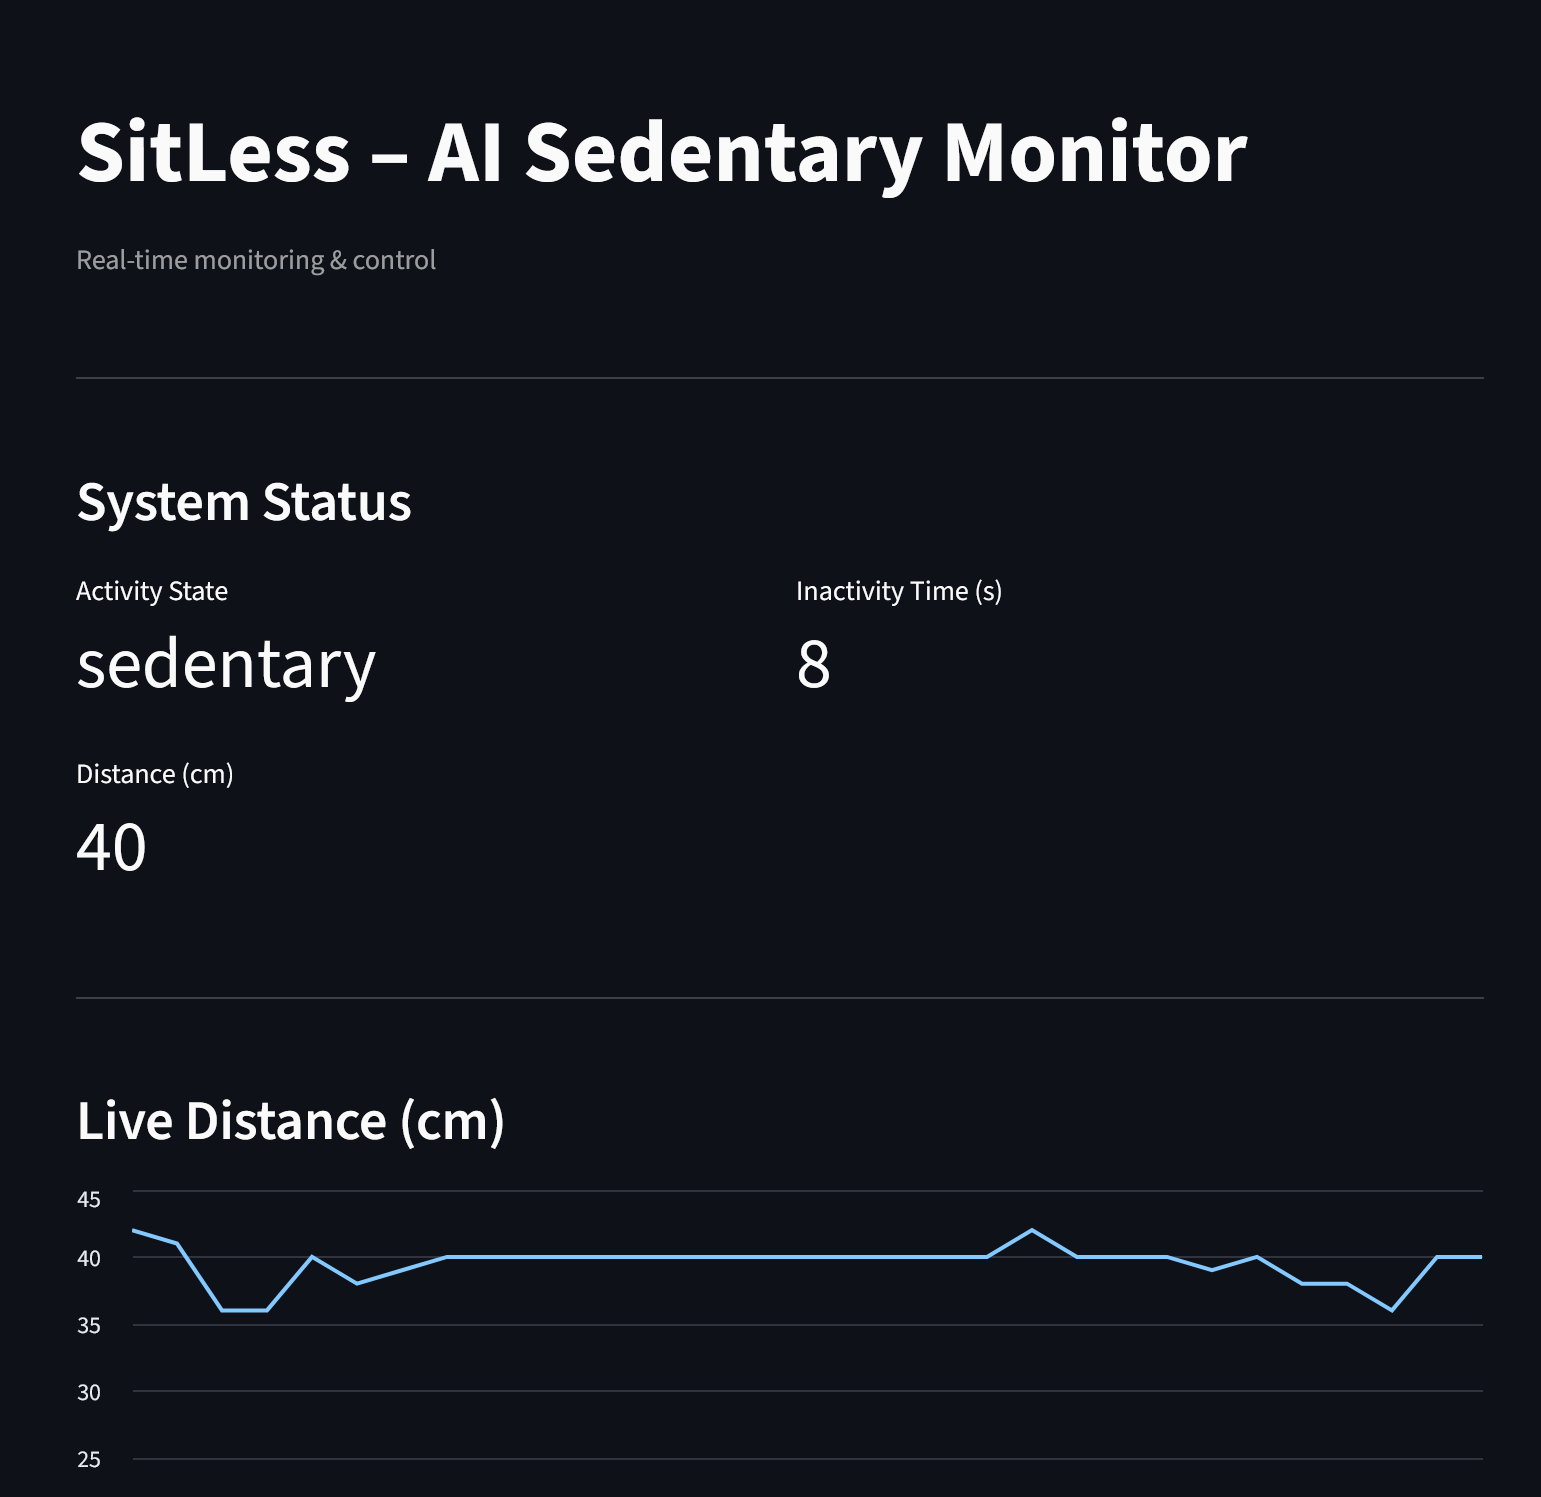

In [ ]:
import streamlit as st
import json
import time
from pathlib import Path
from collections import deque

In [ ]:
# shared JSON files used to communicate with the backend
STATE_FILE = Path("state.json")
COMMANDS_FILE = Path("commands.json")

In [ ]:
# functions to read state and commands from disk
def load_state():
    try:
        with open(STATE_FILE, "r") as f:
            return json.load(f)
    except Exception:
        return {
            "activity": "unknown",
            "distance": None,
            "inactive_time": 0,
            "last_update": 0
        }

def load_commands():
    try:
        with open(COMMANDS_FILE, "r") as f:
            return json.load(f)
    except Exception:
        return {
            "manual_beep": False,
            "manual_tap": False,
            "manual_rest": False,
            "mute": False,
            "tap_enabled": True,
            "system_enabled": True
        }

def save_commands(cmds):
    with open(COMMANDS_FILE, "w") as f:
        json.dump(cmds, f, indent=2)

## Streamlit App Code

In [ ]:
# page config and dashboard title
st.set_page_config(
    page_title="SitLess Dashboard",
    layout="centered"
)

st.title("SitLess – AI Sedentary Monitor")
st.caption("Real-time monitoring & control")

# keep a rolling buffer of the last 45 seconds of distance readings
if "distance_history" not in st.session_state:
    st.session_state.distance_history = deque(maxlen=150)  # ~45s history

# read current state and pending commands from file
state = load_state()
cmds = load_commands()

# add latest distance reading to the graph buffer if valid
if state["distance"] is not None and state["distance"] >= 0:
    st.session_state.distance_history.append(state["distance"])

# show activity state, distance and inactivity timer
st.divider()
st.subheader("System Status")

col1, col2 = st.columns(2)

with col1:
    st.metric("Activity State", state["activity"])
    st.metric(
        "Distance (cm)",
        state["distance"] if state["distance"] is not None else "—"
    )

with col2:
    st.metric("Inactivity Time (s)", state["inactive_time"])

# warn if the backend hasn't sent an update in over 2 seconds
age = time.time() - state.get("last_update", 0)
if age > 2:
    st.warning(f" No backend update for {age:.1f} seconds")

# plot the last 45 seconds of distance readings
st.divider()
st.subheader(" Live Distance (cm)")

if len(st.session_state.distance_history) > 1:
    st.line_chart(list(st.session_state.distance_history))
else:
    st.info("Waiting for distance data…")

# manual buttons for beep, tap and arm reset
st.divider()
st.subheader("Controls")

col1, col2 = st.columns(2)

with col1:
    if st.button(" Manual Beep"):
        cmds["manual_beep"] = True

    if st.button(" Manual Tap"):
        cmds["manual_tap"] = True

    if st.button(" Reset Arm"):
        cmds["manual_rest"] = True

with col2:
    cmds["mute"] = st.checkbox("Mute Buzzer", value=cmds["mute"])
    cmds["tap_enabled"] = st.checkbox("Enable Tap", value=cmds["tap_enabled"])

# turn the whole backend system on or off
st.divider()
st.subheader("System Control")

if cmds["system_enabled"]:
    st.success("System is RUNNING")
    if st.button(" Turn System OFF"):
        cmds["system_enabled"] = False
else:
    st.error("System is STOPPED")
    if st.button(" Turn System ON"):
        cmds["system_enabled"] = True

# write updated commands back to file so the backend picks them up
save_commands(cmds)

# refresh every 300ms to keep the display live
time.sleep(0.3)
st.rerun()